In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


실습2. 선그래프 직접 그리기
- 색·선 스타일·마커를 바꿔 가며 선 그래프 그리기

목표
- 색·선 스타일·마커를 바꿔 가며 선 그래프 그리기

단계
- 설비 데이터를 불러와 A호기 행만 고르기
- 일자와 온도로 기본 선 그래프 그리기
- color·linestyle·marker로 선을 꾸며 다시 그리기

예상 결과
- 기본→색→점선·마커 순으로 바뀌는 선 그래프

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   측정시각    15 non-null     str    
 1   배치      15 non-null     str    
 2   온도      15 non-null     float64
 3   OP값     15 non-null     float64
 4   CP값     15 non-null     float64
 5   상태      15 non-null     str    
dtypes: float64(3), str(3)
memory usage: 852.0 bytes


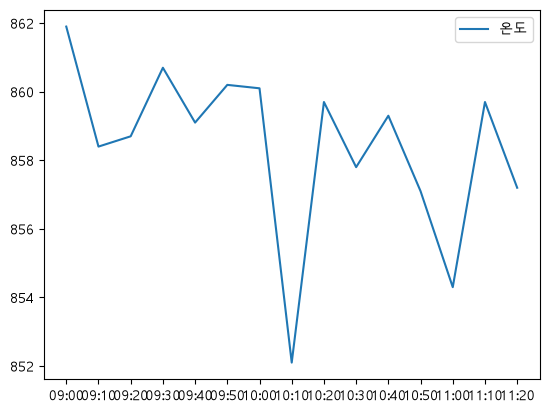

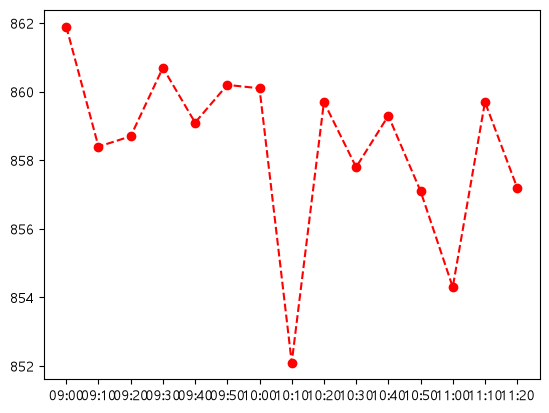

In [2]:
df = pd.read_csv("../data/17_열처리.csv")

# 설비 데이터를 불러와 A호기 행만 고르기
df_a = df[df["배치"] == "로트A"]
df_a.info()
# <class 'pandas.core.frame.DataFrame'>
# Index: 15 entries, 0 to 14
# Data columns (total 6 columns):
#  #   Column  Non-Null Count  Dtype  
# ---  ------  --------------  -----  
#  0   측정시각    15 non-null     object 
#  1   배치      15 non-null     object 
#  2   온도      15 non-null     float64
#  3   OP값     15 non-null     float64
#  4   CP값     15 non-null     float64
#  5   상태      15 non-null     object 
# dtypes: float64(3), object(3)
# memory usage: 840.0+ bytes

# 일자와 온도로 기본 선 그래프 그리기
plt.plot(df_a["측정시각"], df_a["온도"], label = "온도")
plt.legend(loc = "upper right")
plt.show()

# color·linestyle·marker로 선을 꾸며 다시 그리기
plt.plot(df_a["측정시각"], df_a["온도"], color = "red", linestyle = "--", marker = "o")
plt.show()